In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [3]:
df=pd.read_csv("iris_raw.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
dtypes: float64(4)
memory usage: 4.8 KB


In [4]:
df.head(10)

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


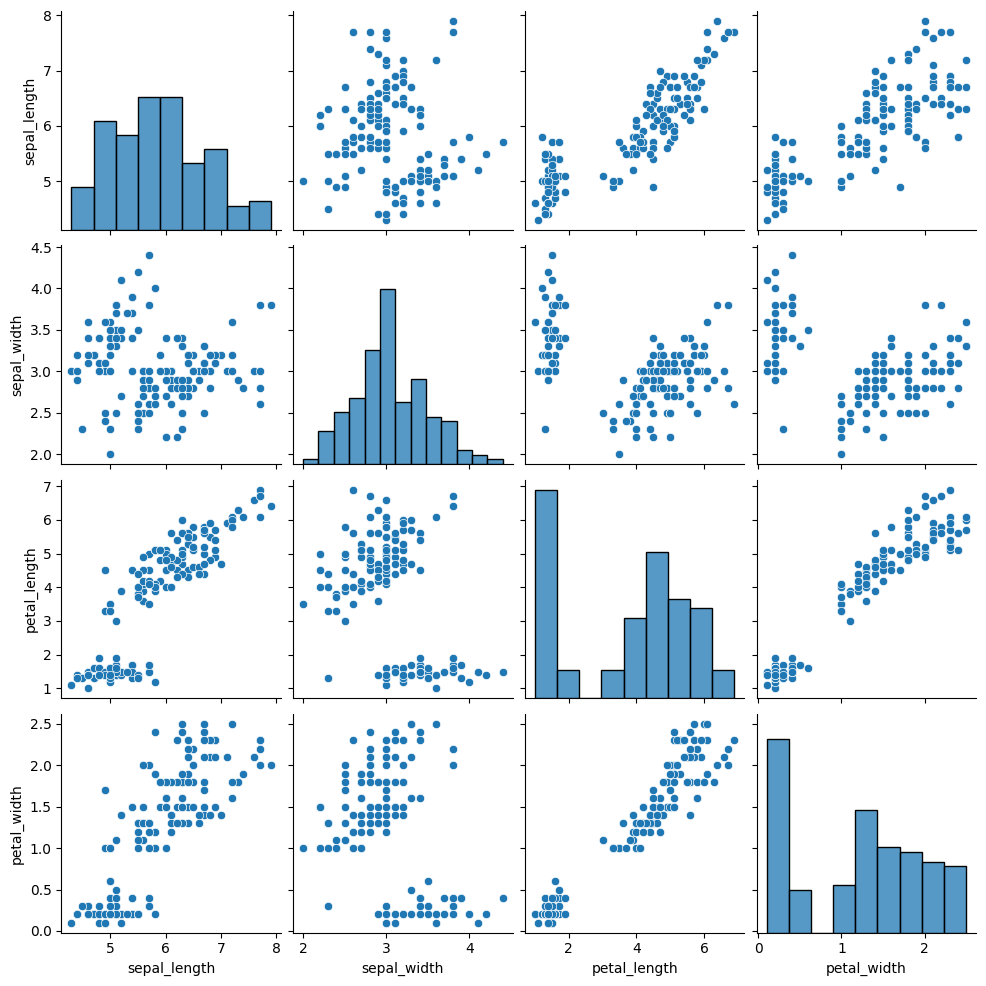

In [5]:
sns.pairplot(data=df)
plt.show()

In [6]:
wcss=list()
for i in range(2,21):
    km=KMeans(init='k-means++',n_clusters=i)
    km.fit(df)
    wcss.append(km.inertia_)

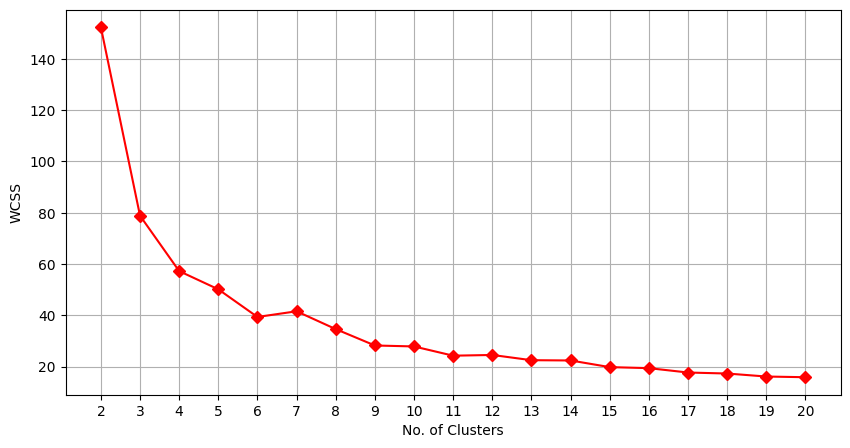

In [7]:
plt.figure(figsize=(10,5))
plt.plot([i for i in range(2,21)],wcss,marker="D",c="red")
plt.xlabel("No. of Clusters")
plt.ylabel("WCSS")
plt.grid(axis="both")
plt.xticks([i for i in range(2,21)])
plt.show()

In [8]:
km=KMeans(init='k-means++',n_clusters=3)
df["species"]=km.fit_predict(df)

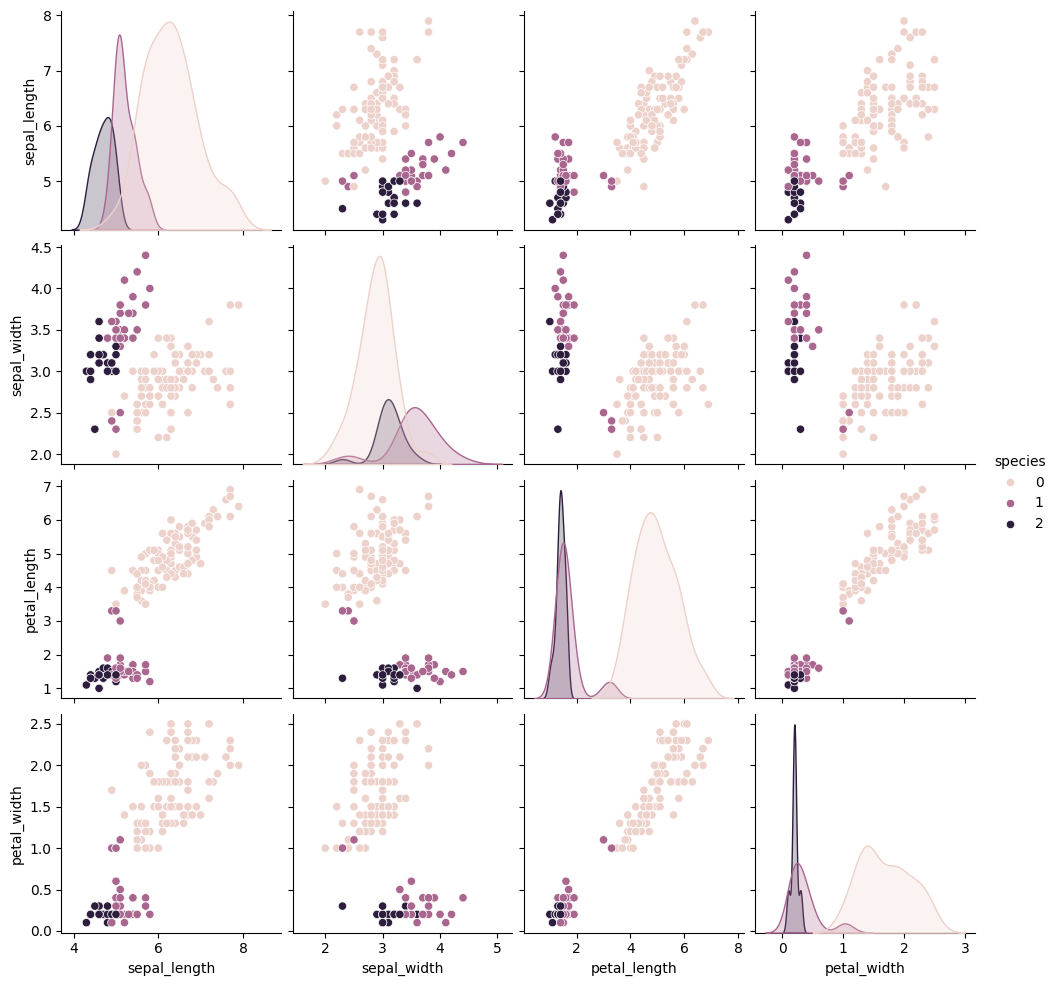

In [9]:
sns.pairplot(data=df,hue="species")
plt.savefig("predicted_k_means.jpg")
plt.show()

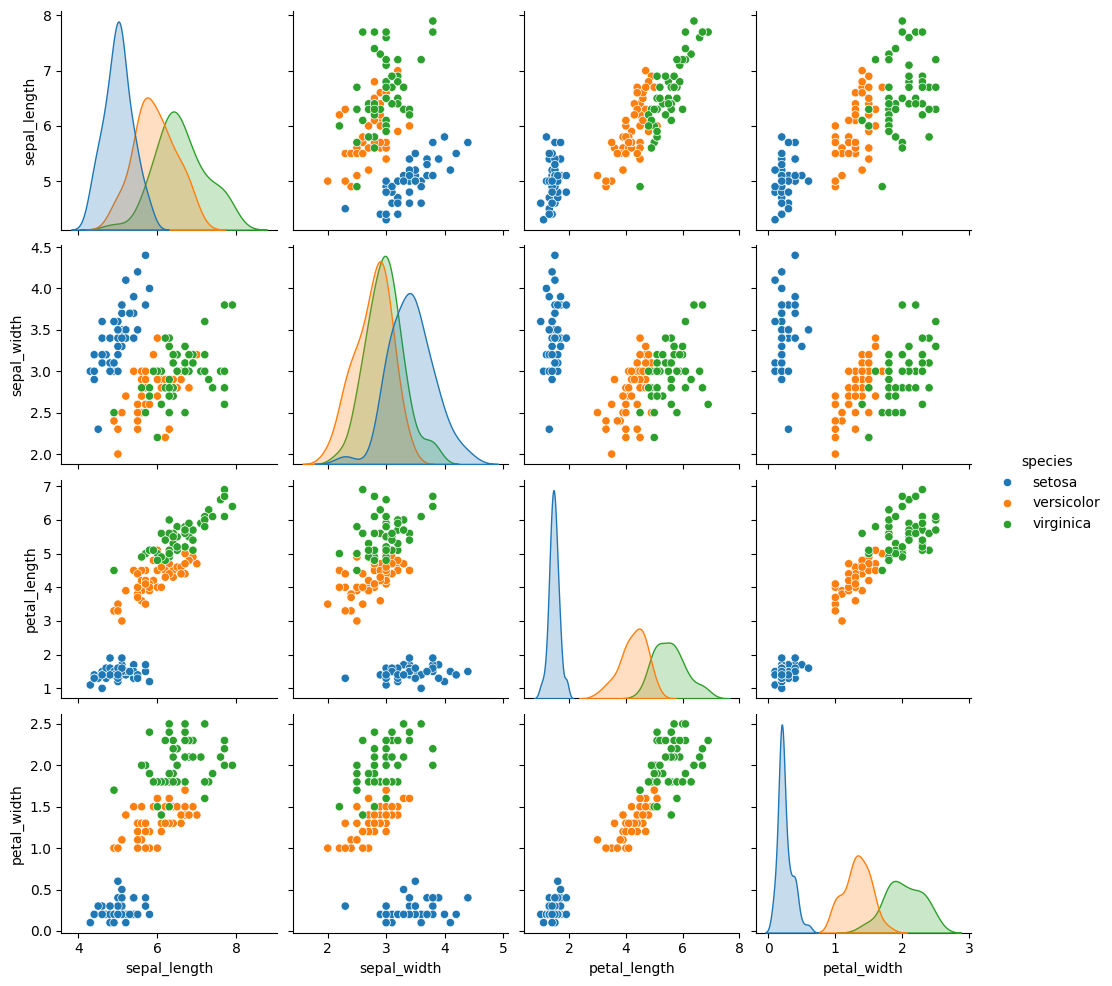

In [10]:
data=pd.read_csv("iris.csv")
sns.pairplot(data=data,hue="species")
plt.savefig("original_k_means.jpg")
plt.show()

SILHOUETTE SCORE

In [11]:
l=[]
for i in range(2,21):
    km1=KMeans(init="k-means++",n_clusters=i)
    km1.fit(df)
    l.append(silhouette_score(df,labels=km1.labels_))

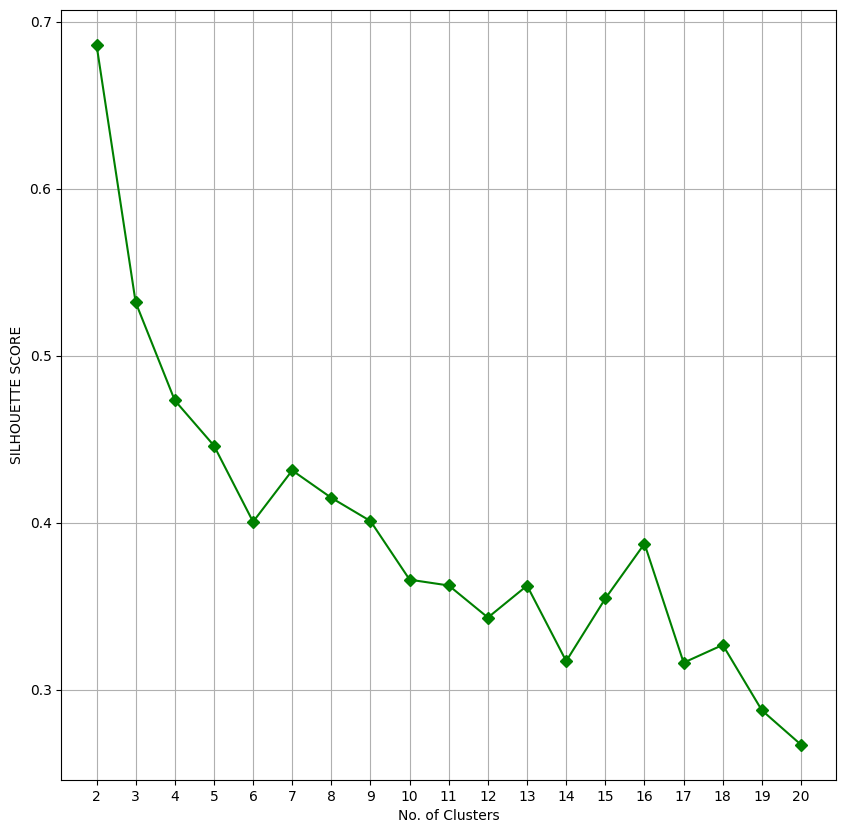

In [12]:
plt.figure(figsize=(10,10))
plt.plot([i for i in range(2,21)],l,marker="D",c="green")
plt.xlabel("No. of Clusters")
plt.ylabel("SILHOUETTE SCORE")
plt.grid(axis="both")
plt.xticks([i for i in range(2,21)])
plt.show()